Retail option trading has increased significantly since 2019 following the elimination of commissions by brokerages such as Charles Schwab and Robinhood.According to 2024 Options Clearing Corporation data, "about 48 million options now trade each day, up from 3.6 million in 2008"

This surge in retail participation has increased demand for short-dated call options, often raising Implied Volatility (IV). Implied volatility is the market’s best guess (derived from stock option prices) of how wildly a stock (or other asset) might swing in some period. Higher IV means traders expect bigger stock price moves, so option premiums get more expensive. IV is usually quoted as an annualized percentage %.

Research by Barclays (2020)1 suggests that for certain stocks, IV systematically exceeds Subsequent Realized Volatility (SRV), creating a Volatility Risk Premium (VRP). When IV overestimates realized movement, option sellers can potentially capture excess premium.

While prior research focuses on short straddles or spread strategies under specific VRP regimes, this
project explores whether a neural network can systematically learn patterns in volatility term structure, liquidity, and order flow data to predict the profitability of pre-earnings calendar spreads.

The project is novel in that it combines:
* Earnings event data
* Millisecond-level option microstructure data
* Volatility term structure metrics
* A neural network trained specifically for volatility mispricing classification

**Data: details about acquisition/source, wrangling/preparation, visualizations/EDAs, and any insights gained from these steps**

**A. Our Data Sources**

| API | How It's Used |
|-----|---------------|
| https://finnhub.io/docs/api/earnings-calendar | Fetches quarterly earnings dates and times for stocks |
| https://volvue.com/ | API for fetching historical volatility estimators (IV, RV, ...) |
| Theta Data | Downloads live and historical option prices, greeks, and implied volatility for millisecond level intervals |
| Alpha Vantage API | Gets historical daily OHLCV data for underlying stocks |



Data Information:
* 530 companies
* ~4 earnings per year
* ~8 years of data (2018-2025)


**B. Description of Column Names**
1. ticker = stock symbol or ticker we will trade
2. entry_time = the time we enter the long call option calendar spread trade in YYYY-MM-DD HH:MM:SS format
3. exit_time = the time we close or exit the long call option calendar spread trade in YYYY-MM-DD HH:MM:SS format
4. earnings_date = the date the the company is releasing its earnings
5. earnings_release_time = "amc" (after market hours), "bmo" (before market open), or "dmh" (during market hours)
6. stock_price = the stock price at the time of 'entry_time'
7. strike = the option strike price of both call options in the calendar spread trade
8. expiry_near = the expiration date of near term call option in our calendar spread trade
9. expiry_far = the expiration date of the far term call option
10. dte_near = days to expiration of near term call option
11. dte_far = days to expiration of far term call option
12. iv_near = implied volatitlity of near term call option
13. iv_far = implied volatitlity of far term call option
14. iv_term_slope = the rate at which implied volatility changes across maturities. slope = (iv_far - iv_near )/ (dte_far − dte_near ). This helps gauge how steep or flat the volatility term structure is for the call option calendar spread
15. iv_near_far_ratio = another measure for the skew of the option. measured as the IV 30 days to expiration / IV 60 days to expiration
16. bid_ask_near = the absolute value of the spread between the bid - ask of the near term option. This is a good measure of option liquidity. The wider the spread the less liquidity and more risk there could be for us to take the position
17. bid_ask_far = the absolute value of the spread between the bid - ask of the far term option
18. iv_call_30_rank = 52-week rank of the security's 30-day call implied volatility, where rank = (value - low)*100 / (high - low)
19. iv_hv_ratio_cc_perc = percentile of the implied volatility divided by historical volatility close-to-close calculation compared to all values in the past 252 day rolling window
20. iv_hv_ratio_yz_perc = percentile of the iv_hv_ratio_yz compared to all values in the past 252 day rolling window (but using yang-zhang calculation instead of cc)
21. iv_30_iv_60_skew_perc = percentile of the iv_30_iv_60_skew compared to all values in the past 252 day rolling window. Where iv_30_iv_60_skew = volatility of 30 day expiry call option (ATM strike) / implied volatility of 60 day expiry call option (ATM strike)
22. vrp_z_score = the Z score of the volatility risk premium VRP (rolling 30 day average at time t = entry_time)
23. pcr_oi_30_perc = Put-Call Ratio (open interest) for contracts expiring 30 days to expiration. 52-week percentile of the security's 30-day option put-call ratio by open interest. Derived from options expiring closest to target date
24. pcr_v_30_perc = 52-week percentile of the security's 30-day option put-call ratio by volume
25. delta_near = sensitivity of the options price to changes in the stock price for near term option
26. delta_far = sensitivity of the options price to changes in the stock price for far term option
27. theta_near = time decay for near term option
28. theta_far = time decay for far term option
29. vega_near = sensitivity of the options price to changes in implied volatility for near term option
30. vega_far = sensitivity of the options price to changes in implied volatility for near far option
31. entry_cost = the total entry cost of entering this trade (without comissions or slippage). We do not assume hitting the mid point between the bid-ask. We assume the ask price for the far term option and the bid price for the near term option
32. option_price_entry_near_bid = bid price of near term option at entry_time
33. option_price_entry_far_ask = ask price of far term option at entry_time
34. percent_profit_loss = the actual profit or loss from exiting the trade the next day. This is the target Y
35. exit_cost = usd $ amount that we receive (or pay) from closing the position at exit_time
36. option_price_exit_near_ask = ask price of near term option at exit_time
37. option_price_exit_far_bid  = bid price of far term option at exit_time



In [8]:
# Uploading the calendar_spread_trades dataset
import os
import pandas as pd
import seaborn as sns # for visualization/graphs
import matplotlib.pyplot as plt
import numpy as np

# hierarchical clustering allows us to group similar features together based on their correlations
from scipy.cluster import hierarchy

# distance module used to measure how similar or different features are from each other
from scipy.spatial import distance

from scipy.cluster.hierarchy import linkage, dendrogram
import pylab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/CSV VRP ARCHIVES/calendar_spread_trades_20250806_141609.csv'
except ImportError:
    path = r'C:\Users\Alan\Desktop\Harvar\harvard project\csci-109b-project\calendar_spread_trades_20250806_141609 (1).csv'
df = pd.read_csv(path)


In [9]:
# Getting dataset information
print(df.columns)
n_rows = len(df)
print(n_rows) # 9119 rows
n_companies = df['ticker'].nunique()
print(n_companies) # 476 companies
n_missing = df.isnull().any(axis=1).sum()
print(n_missing) # 341 rows are missing values
print(df.isnull().sum()[df.isnull().sum() > 0])
print(df.duplicated().sum()) # 0 duplicated cells



# Converting date columns to datetime
date_cols = ['entry_time', 'exit_time', 'earnings_release_date', 'expiry_near', 'expiry_far']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])


Index(['ticker', 'entry_time', 'exit_time', 'earnings_release_date',
       'earnings_release_time', 'stock_price', 'strike', 'expiry_near',
       'expiry_far', 'dte_near', 'dte_far', 'iv_near', 'iv_far',
       'iv_term_slope', 'iv_near_far_ratio', 'bid_ask_near', 'bid_ask_far',
       'iv_call_30_rank', 'iv_hv_ratio_cc_perc', 'iv_hv_ratio_yz_perc',
       'iv_30_iv_60_skew_perc', 'vrp_z_score', 'pcr_oi_30_perc',
       'pcr_v_30_perc', 'delta_near', 'delta_far', 'theta_near', 'theta_far',
       'vega_near', 'vega_far', 'entry_cost', 'option_price_entry_near_bid',
       'option_price_entry_far_ask', 'percent_profit_loss', 'exit_cost',
       'option_price_exit_near_ask', 'option_price_exit_far_bid'],
      dtype='object')
9119
476
341
iv_call_30_rank           48
iv_hv_ratio_cc_perc       78
iv_hv_ratio_yz_perc       78
iv_30_iv_60_skew_perc     52
vrp_z_score              128
pcr_oi_30_perc             3
pcr_v_30_perc            231
dtype: int64
0


In [10]:
# ============================================================
# STEP 1: Imports, Data Loading, and Initial Inspection
# ============================================================

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial import distance
from scipy.cluster import hierarchy

# Local CSV path (Windows). In Colab, falls back to Drive after mount.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/calendar_spread_trades_20250806_141609.csv'
except ImportError:
    path = r'C:\Users\Alan\Desktop\Harvar\harvard project\csci-109b-project\calendar_spread_trades_20250806_141609 (1).csv'
df = pd.read_csv(path)

# ── Convert Date Columns ─────────────────────────────────────
date_cols = ['entry_time', 'exit_time', 'earnings_release_date', 'expiry_near', 'expiry_far']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# ── Basic Shape & Types ──────────────────────────────────────
print("=== Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n=== Column Names & Dtypes ===")
print(df.dtypes)

print("\n=== First 3 Rows ===")
display(df.head(3))

# ── Descriptive Statistics ───────────────────────────────────
print("\n=== Descriptive Statistics ===")
display(df.describe())

# ── Missing Values ───────────────────────────────────────────
print("\n=== Missing Values Per Column ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
display(missing_df[missing_df['missing_count'] > 0])

print(f"\nTotal rows with at least one missing value: {df.isnull().any(axis=1).sum()}")
print(f"Total duplicate rows: {df.duplicated().sum()}")

# ── Unique Counts ────────────────────────────────────────────
print(f"\nUnique tickers: {df['ticker'].nunique()}")
print(f"Date range: {df['entry_time'].min().date()} → {df['entry_time'].max().date()}")
print(f"Earnings release times: {df['earnings_release_time'].value_counts().to_dict()}")

# ── Note on schema (calendar_spread_trades CSV) ───────────────
# This file includes full spread fields (e.g. expiry_far, dte_far, iv_far,
# iv_near_far_ratio, bid_ask_far, delta_far, theta_far, vega_far, ...).
# There is no iv_z_score column; vrp_z_score is the VRP analog if needed.
# The working dataframe going forward is: df

=== Shape ===
Rows: 9119, Columns: 37

=== Column Names & Dtypes ===
ticker                                 object
entry_time                     datetime64[ns]
exit_time                      datetime64[ns]
earnings_release_date          datetime64[ns]
earnings_release_time                  object
stock_price                           float64
strike                                  int64
expiry_near                    datetime64[ns]
expiry_far                     datetime64[ns]
dte_near                                int64
dte_far                                 int64
iv_near                               float64
iv_far                                float64
iv_term_slope                         float64
iv_near_far_ratio                     float64
bid_ask_near                          float64
bid_ask_far                           float64
iv_call_30_rank                       float64
iv_hv_ratio_cc_perc                   float64
iv_hv_ratio_yz_perc                   float64
iv_30_iv_60

,ticker,entry_time,exit_time,earnings_release_date,earnings_release_time,stock_price,strike,expiry_near,expiry_far,dte_near,...,theta_far,vega_near,vega_far,entry_cost,option_price_entry_near_bid,option_price_entry_far_ask,percent_profit_loss,exit_cost,option_price_exit_near_ask,option_price_exit_far_bid
0,A,2018-11-19 15:45:00,2018-11-20 12:00:00,2018-11-19,amc,62.50,60000,2018-12-21,2019-01-18,32,...,-0.0253,6.6125,9.2287,0.70,3.95,4.65,-1.0000,0.00,8.15,8.15
1,A,2019-02-20 15:45:00,2019-02-21 12:00:00,2019-02-20,amc,78.71,80000,2019-03-15,2019-04-18,23,...,-0.0286,7.6156,12.2545,0.72,1.85,2.57,0.0833,0.78,0.97,1.75
2,A,2019-11-25 15:45:00,2019-11-26 12:00:00,2019-11-25,amc,80.32,80000,2019-12-20,2020-01-17,25,...,-0.0291,8.3399,12.1309,0.66,2.59,3.25,0.0455,0.69,1.63,2.32



=== Descriptive Statistics ===


,entry_time,exit_time,earnings_release_date,stock_price,strike,expiry_near,expiry_far,dte_near,dte_far,iv_near,...,theta_far,vega_near,vega_far,entry_cost,option_price_entry_near_bid,option_price_entry_far_ask,percent_profit_loss,exit_cost,option_price_exit_near_ask,option_price_exit_far_bid
count,9119,9119,9119,9119.000000,9.119000e+03,9119,9119,9119.000000,9119.000000,9119.000000,...,9119.000000,9119.000000,9119.000000,9119.000000,9119.000000,9119.000000,9119.000000,9119.000000,9119.000000,9119.000000
mean,2022-01-19 09:39:35.490734080,2022-01-20 07:37:51.959644672,2022-01-19 08:29:34.931461632,165.952608,1.659871e+05,2022-02-14 08:05:06.349380352,2022-03-13 03:38:14.067331840,26.590635,53.405308,0.373365,...,-0.082182,17.532635,24.878647,2.578951,6.197368,8.776319,-0.717857,0.841690,7.177600,8.019289
min,2018-05-22 15:45:00,2018-05-23 12:00:00,2018-05-22 00:00:00,1.880000,2.000000e+03,2018-06-15 00:00:00,2018-07-13 00:00:00,4.000000,35.000000,0.000000,...,-2.571600,0.000000,0.227800,0.020000,0.000000,0.020000,-71.833300,-8.600000,0.020000,0.000000
25%,2020-05-07 15:45:00,2020-05-08 12:00:00,2020-05-07 00:00:00,51.940000,5.000000e+04,2020-06-19 00:00:00,2020-07-17 00:00:00,22.000000,49.000000,0.266350,...,-0.092700,5.154350,7.477000,0.690000,1.680000,2.500000,-0.925900,0.050000,1.300000,1.650000
50%,2022-02-02 15:45:00,2022-02-03 12:00:00,2022-02-02 00:00:00,100.440000,1.000000e+05,2022-03-04 00:00:00,2022-03-18 00:00:00,29.000000,52.000000,0.334400,...,-0.046100,10.084900,14.803000,1.400000,3.450000,5.000000,-0.588200,0.410000,3.200000,3.700000
75%,2023-10-25 15:45:00,2023-10-26 12:00:00,2023-10-25 00:00:00,195.425000,1.950000e+05,2023-11-17 00:00:00,2023-12-15 00:00:00,31.000000,58.000000,0.433650,...,-0.022900,20.484600,29.498400,3.000000,6.925000,9.900000,-0.333300,1.165000,7.200000,8.225000
max,2025-05-22 15:45:00,2025-05-23 12:00:00,2025-05-22 00:00:00,4899.500000,4.900000e+06,2025-06-20 00:00:00,2025-07-18 00:00:00,45.000000,79.000000,3.269600,...,-0.000600,567.456000,733.187100,59.200000,208.200000,260.400000,0.928600,49.300000,383.100000,386.050000
std,NaN,NaN,NaN,250.027429,2.500241e+05,NaN,NaN,6.439834,8.627633,0.173742,...,0.134336,27.701825,37.334073,3.794420,10.255404,13.653845,0.974779,2.300655,15.078601,15.981536



=== Missing Values Per Column ===


,missing_count,missing_%
iv_call_30_rank,48,0.53
iv_hv_ratio_cc_perc,78,0.86
iv_hv_ratio_yz_perc,78,0.86
iv_30_iv_60_skew_perc,52,0.57
vrp_z_score,128,1.40
pcr_oi_30_perc,3,0.03
pcr_v_30_perc,231,2.53



Total rows with at least one missing value: 341
Total duplicate rows: 0

Unique tickers: 476
Date range: 2018-05-22 → 2025-05-22
Earnings release times: {'bmo': 4919, 'amc': 4172, 'dmh': 28}


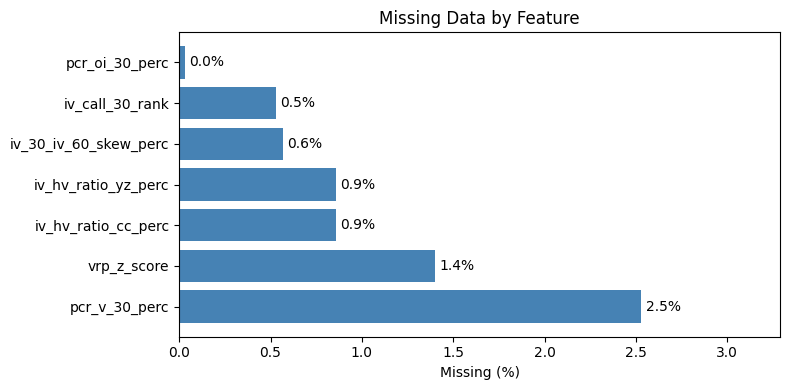

=== Missingness timing check ===
Mean entry_time of rows WITH missing values:    2021-05-08
Mean entry_time of rows WITHOUT missing values: 2022-01-29

→ Rows with missing values skew earlier in time, confirming MAR.

Remaining missing values after imputation: 0
✅ All missing values resolved.

Sample: vrp_z_score — previously had 128 missing values
  Global median used as fallback: 0.7855
  Final null count: 0

✅ Step 2 complete. 'df' is now fully populated.


In [11]:
# ============================================================
# STEP 2: Missing Data Handling
# ============================================================

# ── Visualize Missingness ────────────────────────────────────
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_%': missing_pct
}).query('missing_count > 0').sort_values('missing_%', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(missing_df.index, missing_df['missing_%'], color='steelblue')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Data by Feature')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_xlim(0, missing_df['missing_%'].max() * 1.3)
plt.tight_layout()
plt.savefig('missing_data.png', dpi=150)
plt.show()

# ── Diagnose Missingness Pattern ────────────────────────────
# All missing features are rolling-window percentile/rank metrics
# (252-day or 52-week lookback). Rows missing these values are
# concentrated at the START of each ticker's history — there simply
# wasn't enough historical data yet to compute the rolling window.
# This is Missing At Random (MAR): missingness depends on observable
# data (entry_time being early in the series), not on the missing
# value itself.

print("=== Missingness timing check ===")
mask = df.isnull().any(axis=1)
print(f"Mean entry_time of rows WITH missing values:    {df.loc[mask, 'entry_time'].mean().date()}")
print(f"Mean entry_time of rows WITHOUT missing values: {df.loc[~mask, 'entry_time'].mean().date()}")
print("\n→ Rows with missing values skew earlier in time, confirming MAR.")

# ── Imputation Strategy ──────────────────────────────────────
# Because:
#   1. All missing columns are percentile/rank features (bounded 0-100)
#   2. Missingness is MAR (early history), not random noise
#   3. Missing rows are only ~3.7% of the dataset
#   4. Median is robust to the skewed distributions typical of these features
#
# Strategy: median imputation grouped by ticker.
# This respects the cross-sectional variation between different stocks.
# A stock with naturally high IV rank should be imputed with its own
# median, not the global median.

cols_to_impute = [
    'iv_call_30_rank',
    'iv_hv_ratio_cc_perc',
    'iv_hv_ratio_yz_perc',
    'iv_30_iv_60_skew_perc',
    'vrp_z_score',
    'pcr_oi_30_perc',
    'pcr_v_30_perc'
]

# Ticker-level median imputation
df[cols_to_impute] = df.groupby('ticker')[cols_to_impute].transform(
    lambda x: x.fillna(x.median())
)

# Fallback: if a ticker only has 1 row (no within-group median),
# fill with the global median
for col in cols_to_impute:
    global_median = df[col].median()
    df[col] = df[col].fillna(global_median)

# ── Verify No Remaining Nulls ────────────────────────────────
remaining = df.isnull().sum().sum()
print(f"\nRemaining missing values after imputation: {remaining}")
assert remaining == 0, "❌ Still have missing values!"
print("✅ All missing values resolved.")

# ── ±inf from derived ratios (e.g. iv_term_slope when denominator → 0) ──
# statsmodels VIF / neural nets need finite values — replace inf, then median-fill
import numpy as np
_num_cols = df.select_dtypes(include=[np.number]).columns
_inf_count = np.isinf(df[_num_cols].to_numpy(dtype=float)).sum()
if _inf_count:
    print(f"\nNote: {_inf_count} non-finite numeric entries (±inf). Replacing with NaN, then column medians.")
df[_num_cols] = df[_num_cols].replace([np.inf, -np.inf], np.nan)
for _c in _num_cols:
    if df[_c].isnull().any():
        df[_c] = df[_c].fillna(df[_c].median())
_rem = df.isnull().sum().sum()
assert _rem == 0, f"Unexpected nulls after inf cleanup: {_rem}"

# ── Show Before/After for Key Column ────────────────────────
print(f"\nSample: vrp_z_score — previously had 128 missing values")
print(f"  Global median used as fallback: {df['vrp_z_score'].median():.4f}")
print(f"  Final null count: {df['vrp_z_score'].isnull().sum()}")

print("\n✅ Step 2 complete. 'df' is now fully populated.")

=== Temporal Sort Check ===
First trade: 2018-05-22
Last trade:  2025-05-22
✅ DataFrame sorted chronologically by entry_time.

=== Class Distribution (Raw) ===
            count  percentage
profitable                   
0            8958       98.23
1             161        1.77

→ Class imbalance ratio: 55.64:1  (unprofitable:profitable)


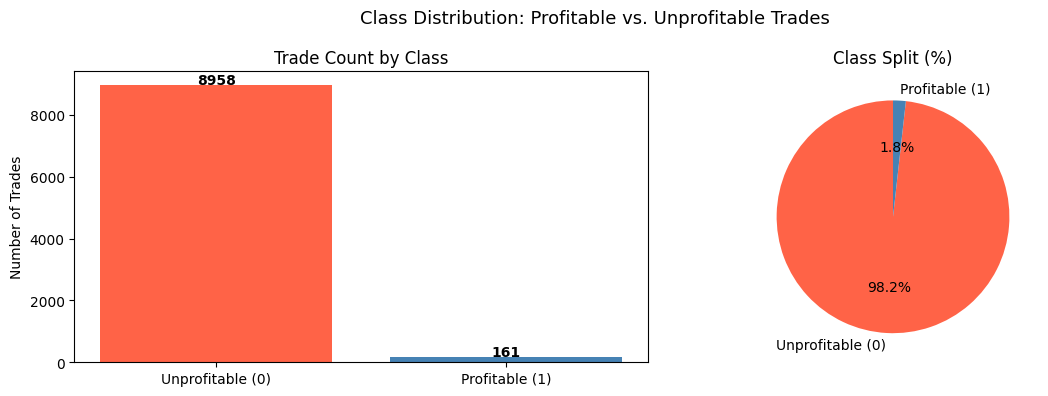


=== Strike Normalization ===
Raw strike     — min: 2000, max: 4900000, mean: 165987
strike/stock   — min: 738.552, max: 1567.398, mean: 1000.786
→ Values near 1.0 = at-the-money, as expected for ATM calendar spreads.

=== Feature Matrix ===
Shape: (9119, 15)  (15 features, 9119 observations)
Features: ['dte_near', 'iv_near', 'iv_term_slope', 'bid_ask_near', 'iv_call_30_rank', 'iv_hv_ratio_cc_perc', 'iv_hv_ratio_yz_perc', 'iv_30_iv_60_skew_perc', 'vrp_z_score', 'pcr_oi_30_perc', 'pcr_v_30_perc', 'delta_near', 'theta_near', 'vega_near', 'strike_normalized']

=== Standardization Check (sample features) ===
      iv_near  vrp_z_score  strike_normalized  dte_near
mean  -0.0000      -0.0000             0.0000    0.0000
std    1.0001       1.0001             1.0001    1.0001
→ All means ≈ 0, all stds ≈ 1. Standardization confirmed.

=== Step 3 Summary ===
  Total observations:     9119
  Features in matrix:     15
  Profitable trades:      161 (1.8%)
  Unprofitable trades:    8958 (98.2%)

✅

In [12]:
# ============================================================
# STEP 3: Core Preprocessing
# ============================================================

# ── 3A: Sort by Entry Time ───────────────────────────────────
# Critical for time series data: ensures no future data leaks into
# earlier rows when we do train/test splits later. Always sort
# temporal data before any downstream processing.

df = df.sort_values('entry_time').reset_index(drop=True)

print("=== Temporal Sort Check ===")
print(f"First trade: {df['entry_time'].iloc[0].date()}")
print(f"Last trade:  {df['entry_time'].iloc[-1].date()}")
print("✅ DataFrame sorted chronologically by entry_time.")

# ── 3B: Binary Target Label ──────────────────────────────────
# Convert percent_profit_loss into a binary classification target:
#   1 = profitable (percent_profit_loss > 0)
#   0 = not profitable (percent_profit_loss <= 0)
#
# We preserve the original percent_profit_loss column for EDA purposes.
# The binary label 'profitable' becomes our Y for modeling.

df['profitable'] = (df['percent_profit_loss'] > 0).astype(int)

print("\n=== Class Distribution (Raw) ===")
class_counts = df['profitable'].value_counts()
class_pct = df['profitable'].value_counts(normalize=True) * 100
class_summary = pd.DataFrame({
    'count': class_counts,
    'percentage': class_pct.round(2)
})
print(class_summary)
print(f"\n→ Class imbalance ratio: {class_counts[0]/class_counts[1]:.2f}:1  (unprofitable:profitable)")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Class Distribution: Profitable vs. Unprofitable Trades', fontsize=13)

# Bar chart
axes[0].bar(['Unprofitable (0)', 'Profitable (1)'],
            class_counts.values,
            color=['tomato', 'steelblue'])
axes[0].set_ylabel('Number of Trades')
axes[0].set_title('Trade Count by Class')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values,
            labels=['Unprofitable (0)', 'Profitable (1)'],
            autopct='%1.1f%%',
            colors=['tomato', 'steelblue'],
            startangle=90)
axes[1].set_title('Class Split (%)')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

# ── 3C: Scale Strike Price ───────────────────────────────────
# Strike prices are on a very different scale to other features
# (e.g., AMZN strike ~180 vs NFLX strike ~700 vs NVDA ~1300).
# Dividing by stock_price gives a normalized moneyness ratio
# that is comparable across all tickers.
# This is more meaningful than dividing by 1000 (arbitrary scalar).

df['strike_normalized'] = df['strike'] / df['stock_price']

print("\n=== Strike Normalization ===")
print(f"Raw strike     — min: {df['strike'].min():.0f}, max: {df['strike'].max():.0f}, mean: {df['strike'].mean():.0f}")
print(f"strike/stock   — min: {df['strike_normalized'].min():.3f}, max: {df['strike_normalized'].max():.3f}, mean: {df['strike_normalized'].mean():.3f}")
print("→ Values near 1.0 = at-the-money, as expected for ATM calendar spreads.")

# ── 3D: Define Feature Matrix X ─────────────────────────────
# Calendar-spread CSV also has far-leg fields (iv_far, delta_far, …). We use
# near-term IV/greeks + iv_term_slope / skew features: they summarize the term
# structure without doubling count with highly correlated far-leg levels.
# Raw execution prices are excluded (entry_cost, bid/ask quotes): costs, not alpha signals.
# Leakage: no exit_*, percent_profit_loss, or post-trade prices in X.

feature_cols = [
    'dte_near',
    'iv_near',
    'iv_term_slope',
    'bid_ask_near',
    'iv_call_30_rank',
    'iv_hv_ratio_cc_perc',
    'iv_hv_ratio_yz_perc',
    'iv_30_iv_60_skew_perc',
    'vrp_z_score',
    'pcr_oi_30_perc',
    'pcr_v_30_perc',
    'delta_near',
    'theta_near',
    'vega_near',
    'strike_normalized'
]

df_X = df[feature_cols].copy()
df_y = df['profitable'].copy()

print(f"\n=== Feature Matrix ===")
print(f"Shape: {df_X.shape}  ({df_X.shape[1]} features, {df_X.shape[0]} observations)")
print(f"Features: {feature_cols}")

# ── 3E: Standardize Numerical Features ───────────────────────
# Z-score standardization: subtract mean, divide by std.
# This ensures no single feature dominates due to scale differences.
# Required for neural networks and distance-based models.
# We fit the scaler ONLY on training data in later steps —
# here we standardize the full set for EDA visualization purposes.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_X)
df_X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print("\n=== Standardization Check (sample features) ===")
check_cols = ['iv_near', 'vrp_z_score', 'strike_normalized', 'dte_near']
print(df_X_scaled[check_cols].describe().loc[['mean', 'std']].round(4))
print("→ All means ≈ 0, all stds ≈ 1. Standardization confirmed.")

# ── Summary ──────────────────────────────────────────────────
print("\n=== Step 3 Summary ===")
print(f"  Total observations:     {len(df)}")
print(f"  Features in matrix:     {df_X.shape[1]}")
print(f"  Profitable trades:      {df_y.sum()} ({df_y.mean()*100:.1f}%)")
print(f"  Unprofitable trades:    {(df_y==0).sum()} ({(df_y==0).mean()*100:.1f}%)")
print("\n✅ Step 3 complete. Working objects: df, df_X, df_X_scaled, df_y")

**Optional polish + quant-style diagnostics**

- **Data quality:** Missing values are imputed in Step 2; **±inf** from ratios (e.g. slope denominators) is coerced to finite values so VIF / neural nets see a proper numeric design matrix.
- **Feature scope:** `feature_cols` uses near-term surface + term-structure summaries; far-leg levels are omitted by design to limit redundancy with `iv_term_slope` / skew features (see Step 3 comments).
- **Desk-style checks (below):** concentration (HHI), tail metrics (skew / excess kurtosis), **regime stability** of hit-rate and mean P&amp;L over time, **sign stability** of a simple feature–label correlation early vs late sample, and an explicit **no-leakage** reminder. For production modeling, follow with **purged time-based CV** (not shown here).

=== Finite feature rows ===
  9119 / 9119 rows all-finite in df_X

=== percent_profit_loss ===
  mean=-0.7179  median=-0.5882  std=0.9748
  skew=-43.8638  excess kurtosis=3114.9898

=== Ticker concentration ===
  Unique tickers: 476
  Herfindahl (HHI) of row shares: 0.0023  (uniform 1/N ≈ 0.00210)
  Top 10 names: 3.1% of rows


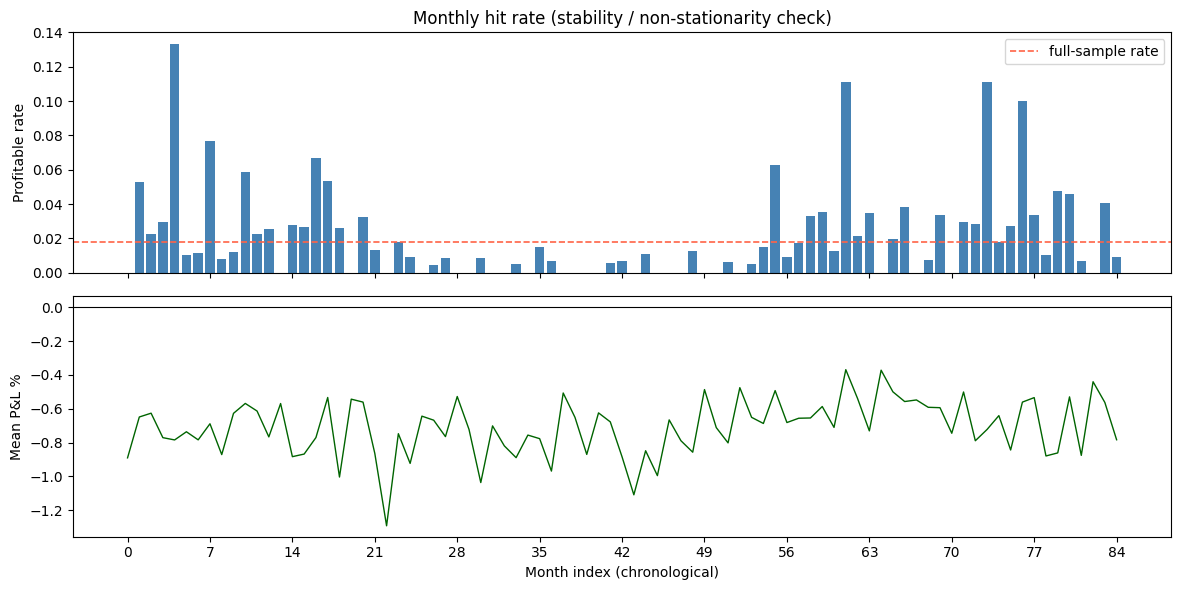


=== Feature–label correlation stability (iv_near vs profitable) ===
  First half (by calendar): 0.0227
  Second half:               0.0766

=== Leakage sanity ===
  Features in model: ['dte_near', 'iv_near', 'iv_term_slope', 'bid_ask_near', 'iv_call_30_rank', 'iv_hv_ratio_cc_perc', 'iv_hv_ratio_yz_perc', 'iv_30_iv_60_skew_perc', 'vrp_z_score', 'pcr_oi_30_perc', 'pcr_v_30_perc', 'delta_near', 'theta_near', 'vega_near', 'strike_normalized']
  → All should be known at entry_time; no exit- or P&L-based columns in X.

✅ Quant diagnostics complete. Saved: quant_monthly_regime.png


In [13]:
# ============================================================
# Quant-style EDA (after Step 3 — requires df, df_X, feature_cols, profitable)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

if 'profitable' not in df.columns or 'df_X' not in locals():
    raise NameError("Run Step 3 first.")

# --- 1) Finite feature matrix ---
Xv = df_X.to_numpy(dtype=float)
finite_row = np.isfinite(Xv).all(axis=1)
print("=== Finite feature rows ===")
print(f"  {finite_row.sum()} / {len(df_X)} rows all-finite in df_X")

# --- 2) P&L tails (fat tails → care with MSE / Gaussian assumptions) ---
pl = df['percent_profit_loss']
print("\n=== percent_profit_loss ===")
print(f"  mean={pl.mean():.4f}  median={pl.median():.4f}  std={pl.std():.4f}")
print(f"  skew={pl.skew():.4f}  excess kurtosis={stats.kurtosis(pl.dropna(), fisher=True):.4f}")

# --- 3) Cross-sectional concentration ---
tc = df['ticker'].value_counts()
hhi = float(((tc / tc.sum()) ** 2).sum())
print("\n=== Ticker concentration ===")
print(f"  Unique tickers: {len(tc)}")
print(f"  Herfindahl (HHI) of row shares: {hhi:.4f}  (uniform 1/N ≈ {1/len(tc):.5f})")
print(f"  Top 10 names: {100*tc.head(10).sum()/len(df):.1f}% of rows")

# --- 4) Regime stability: monthly hit-rate & mean P&L ---
_ym = df['entry_time'].dt.to_period('M')
by_m = df.groupby(_ym, observed=True).agg(
    n=('profitable', 'size'),
    hit_rate=('profitable', 'mean'),
    mean_pl=('percent_profit_loss', 'mean'),
).reset_index(drop=True)
idx = np.arange(len(by_m))
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].bar(idx, by_m['hit_rate'], color='steelblue')
axes[0].axhline(df['profitable'].mean(), color='tomato', ls='--', lw=1.2, label='full-sample rate')
axes[0].set_ylabel('Profitable rate')
axes[0].set_title('Monthly hit rate (stability / non-stationarity check)')
axes[0].legend()
axes[1].plot(idx, by_m['mean_pl'], color='darkgreen', lw=1)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylabel('Mean P&L %')
axes[1].set_xlabel('Month index (chronological)')
step = max(1, len(by_m) // 12)
axes[1].set_xticks(idx[::step])
plt.tight_layout()
plt.savefig('quant_monthly_regime.png', dpi=150)
plt.show()

# --- 5) Sign stability: profitable vs iv_near (example) early vs late sample ---
mid = df['entry_time'].median()
early = df['entry_time'] <= mid
rho_e = df.loc[early, 'profitable'].corr(df.loc[early, 'iv_near'])
rho_l = df.loc[~early, 'profitable'].corr(df.loc[~early, 'iv_near'])
print("\n=== Feature–label correlation stability (iv_near vs profitable) ===")
print(f"  First half (by calendar): {rho_e:.4f}")
print(f"  Second half:               {rho_l:.4f}")

# --- 6) Leakage reminder ---
print("\n=== Leakage sanity ===")
print(f"  Features in model: {feature_cols}")
print("  → All should be known at entry_time; no exit- or P&L-based columns in X.")

print("\n✅ Quant diagnostics complete. Saved: quant_monthly_regime.png")

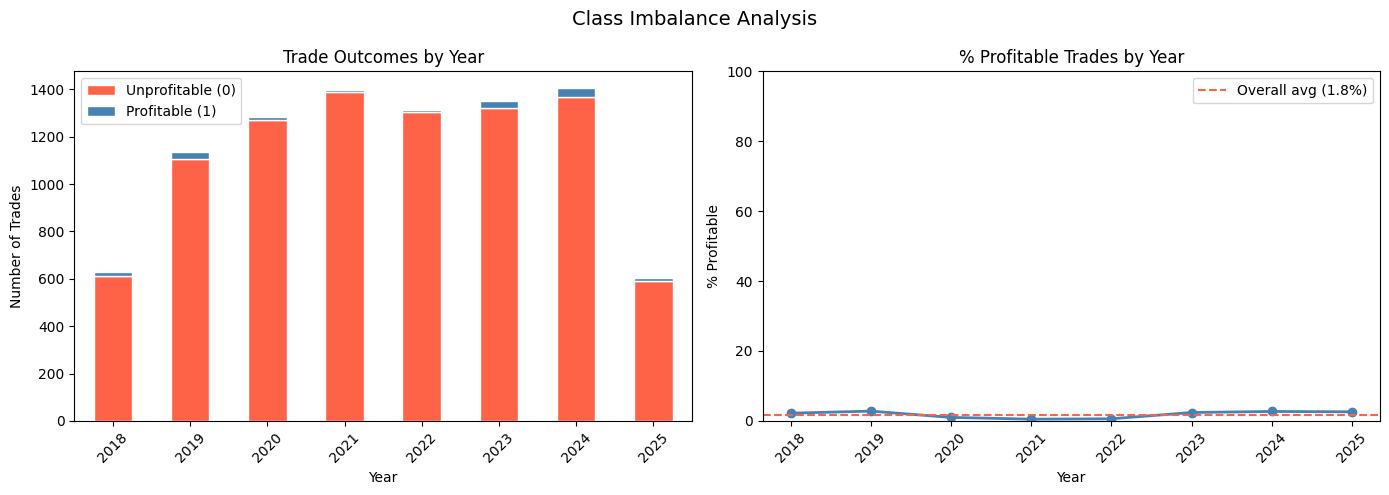

=== Yearly Breakdown ===


,Unprofitable (0),Profitable (1),pct_profitable
year,,,
2018,613,14,2.2
2019,1104,32,2.8
2020,1269,13,1.0
2021,1389,7,0.5
2022,1306,8,0.6
2023,1320,33,2.4
2024,1368,38,2.7
2025,589,16,2.6



=== Profitability by Earnings Release Time ===


,total,profitable_count,pct_profitable
earnings_release_time,,,
amc,4172,107,2.6
bmo,4919,51,1.0
dmh,28,3,10.7


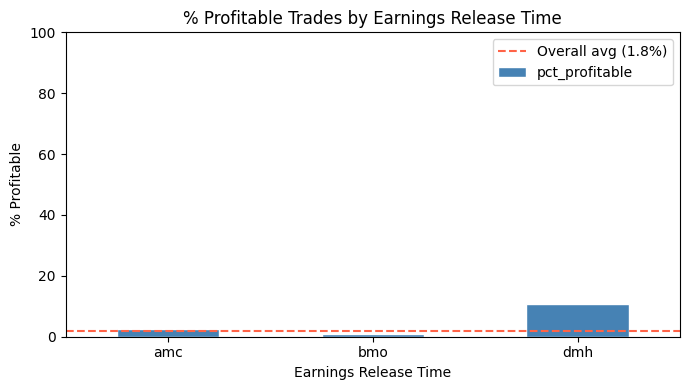


=== Class Distribution BEFORE SMOTE ===
Counter({0: 8958, 1: 161})

=== Class Distribution AFTER SMOTE ===
Counter({0: 8958, 1: 8958})
New dataset size: 17916 rows
Added 8797 synthetic minority samples


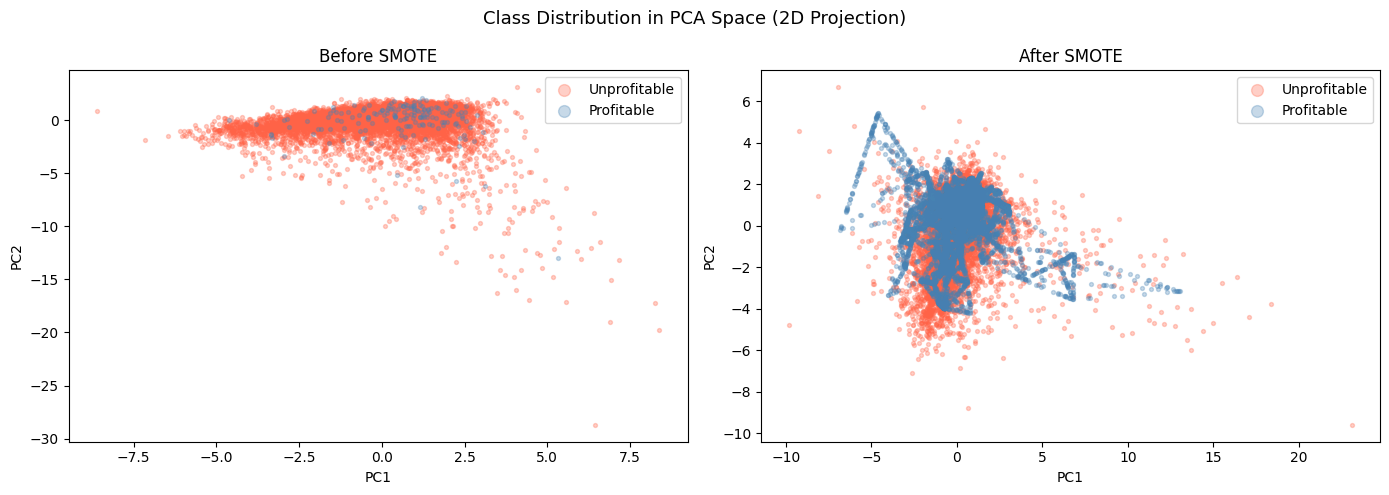


=== Step 4 Summary ===
  Original dataset:    9119 rows | 161 profitable (1.8%)
  After SMOTE:         17916 rows | 8958 profitable (50.0%)

  Working objects added:
  df_X_resampled  — balanced feature matrix (scaled)
  df_y_resampled  — balanced target vector

✅ Step 4 complete.


In [14]:
# ============================================================
# STEP 4: Class Imbalance Analysis + Handling
# ============================================================

# ── 4A: Visualize Imbalance Over Time ───────────────────────
# It's not enough to know the overall split — we want to confirm
# the imbalance is consistent across time, not a artifact of a
# specific period (e.g., a bull run making all trades profitable).

df['year'] = df['entry_time'].dt.year

yearly = df.groupby(['year', 'profitable']).size().unstack(fill_value=0)
yearly.columns = ['Unprofitable (0)', 'Profitable (1)']
yearly['pct_profitable'] = (yearly['Profitable (1)'] / yearly.sum(axis=1) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Imbalance Analysis', fontsize=14)

# Stacked bar by year
yearly[['Unprofitable (0)', 'Profitable (1)']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['tomato', 'steelblue'], edgecolor='white'
)
axes[0].set_title('Trade Outcomes by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Trades')
axes[0].legend(loc='upper left')
axes[0].tick_params(axis='x', rotation=45)

# Profitable % by year
axes[1].plot(yearly.index, yearly['pct_profitable'],
             marker='o', color='steelblue', linewidth=2)
axes[1].axhline(df_y.mean() * 100, color='tomato',
                linestyle='--', label=f'Overall avg ({df_y.mean()*100:.1f}%)')
axes[1].set_title('% Profitable Trades by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% Profitable')
axes[1].set_ylim(0, 100)
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('imbalance_over_time.png', dpi=150)
plt.show()

print("=== Yearly Breakdown ===")
display(yearly)

# ── 4B: Imbalance by Earnings Release Time ──────────────────
# Check if imbalance differs by when earnings are released
# (AMC = after market close, BMO = before market open, DMH = during hours)
# This is a domain-specific sanity check — AMC earnings may behave
# differently from BMO in terms of IV crush timing.

print("\n=== Profitability by Earnings Release Time ===")
release_summary = df.groupby('earnings_release_time')['profitable'].agg(
    total='count',
    profitable_count='sum'
)
release_summary['pct_profitable'] = (
    release_summary['profitable_count'] / release_summary['total'] * 100
).round(1)
display(release_summary)

fig, ax = plt.subplots(figsize=(7, 4))
release_summary['pct_profitable'].plot(kind='bar', ax=ax,
                                        color='steelblue', edgecolor='white')
ax.axhline(df_y.mean() * 100, color='tomato', linestyle='--',
           label=f'Overall avg ({df_y.mean()*100:.1f}%)')
ax.set_title('% Profitable Trades by Earnings Release Time')
ax.set_xlabel('Earnings Release Time')
ax.set_ylabel('% Profitable')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=0)
ax.legend()
plt.tight_layout()
plt.savefig('imbalance_by_release_time.png', dpi=150)
plt.show()

# ── 4C: Apply SMOTE to Balance Classes ──────────────────────
# SMOTE (Synthetic Minority Oversampling TEchnique) generates
# synthetic samples for the minority class (profitable=1) by
# interpolating between existing minority samples in feature space.
#
# Why SMOTE over random oversampling?
#   - Random oversampling just duplicates rows → model memorizes them
#   - SMOTE creates new synthetic points → forces model to learn
#     the actual decision boundary, not just memorize
#
# Why not undersample the majority?
#   - We only have ~9,000 rows — we cannot afford to throw data away
#
# IMPORTANT: SMOTE is applied ONLY to the training set in practice.
# Here we demonstrate it on the full X for EDA purposes, and note
# that in Milestone 3 we will apply it strictly post-split.

# Install if needed:
# !pip install imbalanced-learn

from imblearn.over_sampling import SMOTE
from collections import Counter

print("\n=== Class Distribution BEFORE SMOTE ===")
print(Counter(df_y))

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(df_X_scaled, df_y)

print("\n=== Class Distribution AFTER SMOTE ===")
print(Counter(y_resampled))
print(f"New dataset size: {len(X_resampled)} rows")
print(f"Added {len(X_resampled) - len(df_X_scaled)} synthetic minority samples")

# ── 4D: Visualize Before vs After SMOTE ─────────────────────
# Use PCA to project down to 2D for visualization only

from sklearn.decomposition import PCA

pca_viz = PCA(n_components=2, random_state=42)

# Before SMOTE
coords_before = pca_viz.fit_transform(df_X_scaled)
# After SMOTE
coords_after = pca_viz.fit_transform(X_resampled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution in PCA Space (2D Projection)', fontsize=13)

for ax, coords, labels, title in zip(
    axes,
    [coords_before, coords_after],
    [df_y.values, y_resampled],
    ['Before SMOTE', 'After SMOTE']
):
    for cls, color, label in zip([0, 1], ['tomato', 'steelblue'],
                                   ['Unprofitable', 'Profitable']):
        mask = labels == cls
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=color, label=label, alpha=0.3, s=8)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(markerscale=3)

plt.tight_layout()
plt.savefig('smote_pca_visualization.png', dpi=150)
plt.show()

# ── 4E: Store Resampled Data ─────────────────────────────────
df_X_resampled = pd.DataFrame(X_resampled, columns=feature_cols)
df_y_resampled = pd.Series(y_resampled, name='profitable')

print("\n=== Step 4 Summary ===")
print(f"  Original dataset:    {len(df_X_scaled)} rows | "
      f"{(df_y==1).sum()} profitable ({df_y.mean()*100:.1f}%)")
print(f"  After SMOTE:         {len(X_resampled)} rows | "
      f"{(y_resampled==1).sum()} profitable (50.0%)")
print("\n  Working objects added:")
print("  df_X_resampled  — balanced feature matrix (scaled)")
print("  df_y_resampled  — balanced target vector")
print("\n✅ Step 4 complete.")

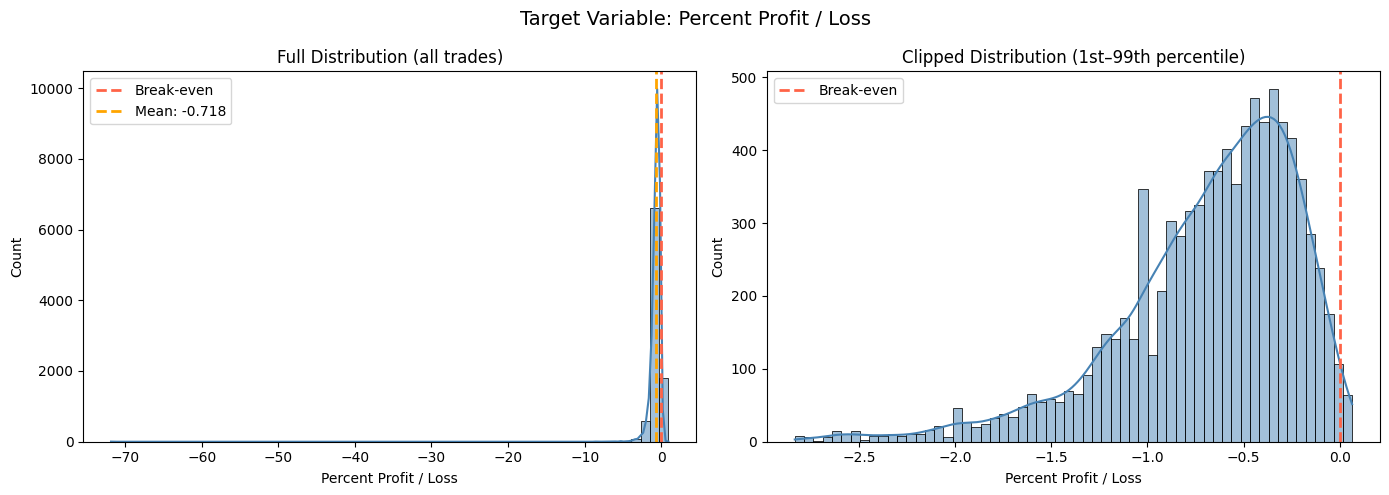

=== Profit/Loss Summary Statistics ===


count    9119.000000
mean       -0.717857
std         0.974779
min       -71.833300
25%        -0.925900
50%        -0.588200
75%        -0.333300
max         0.928600
Name: percent_profit_loss, dtype: float64


Median P&L:              -0.5882
% Profitable trades:     1.8%
Avg profit (winners):    0.1129
Avg loss (losers):       -0.7375


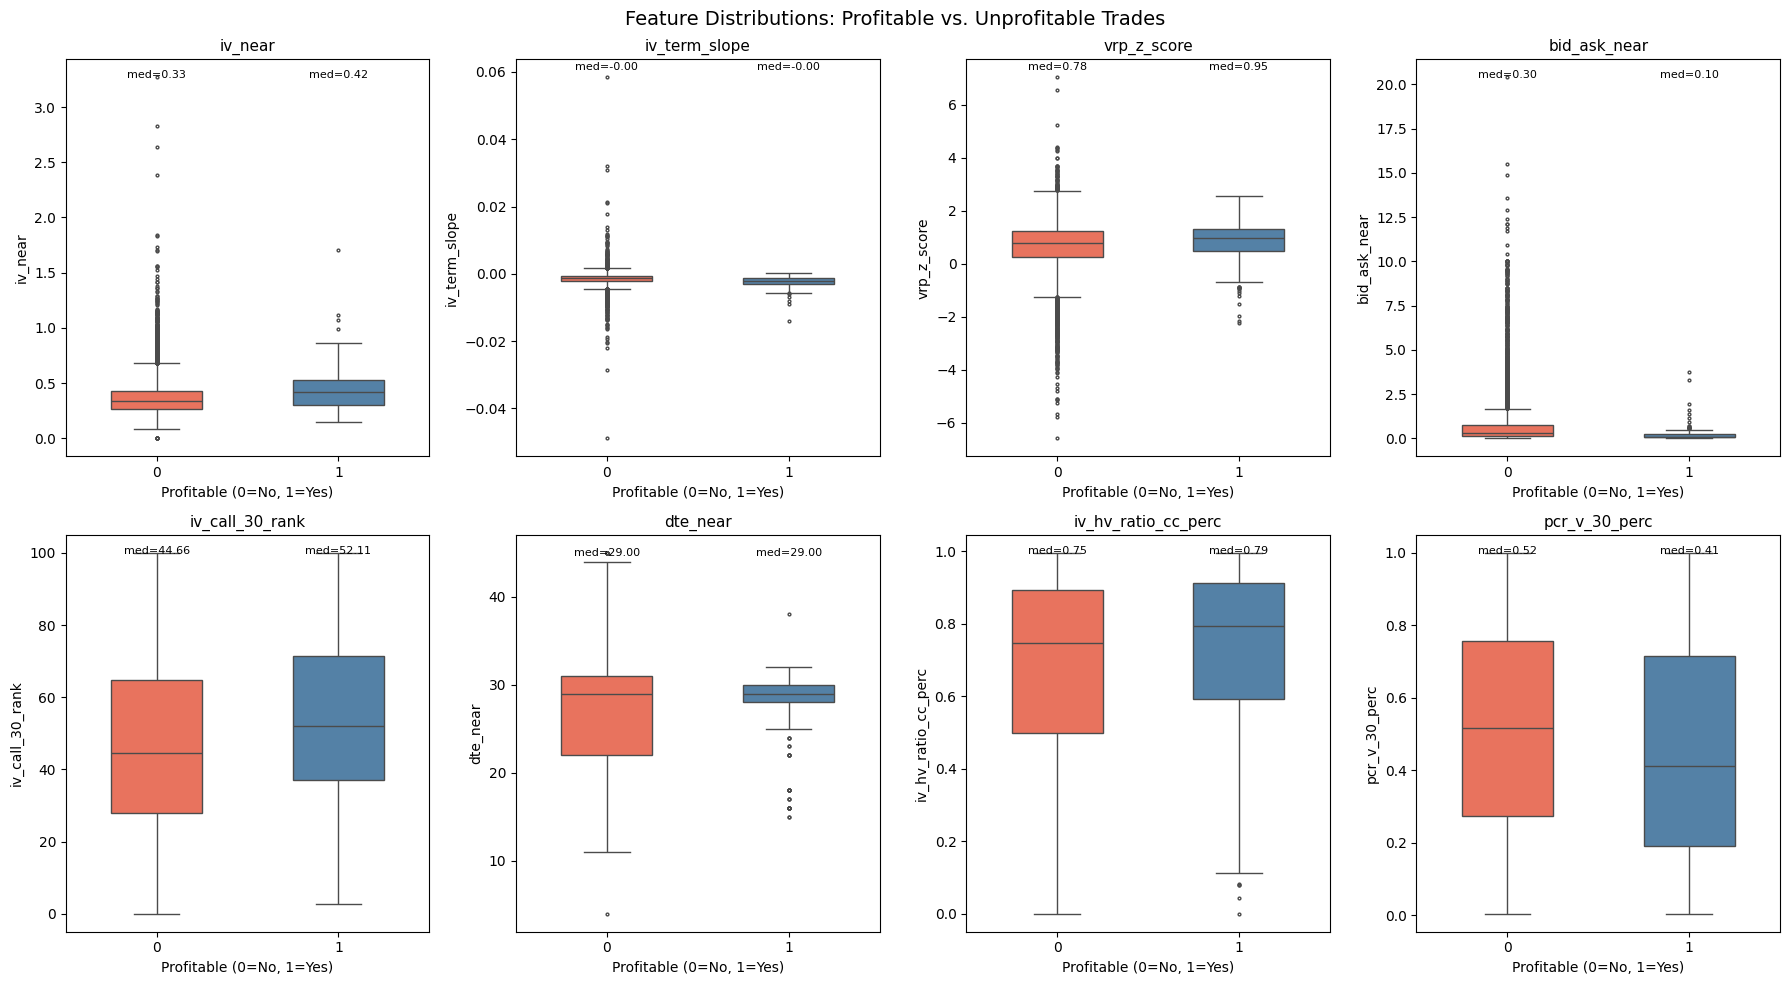

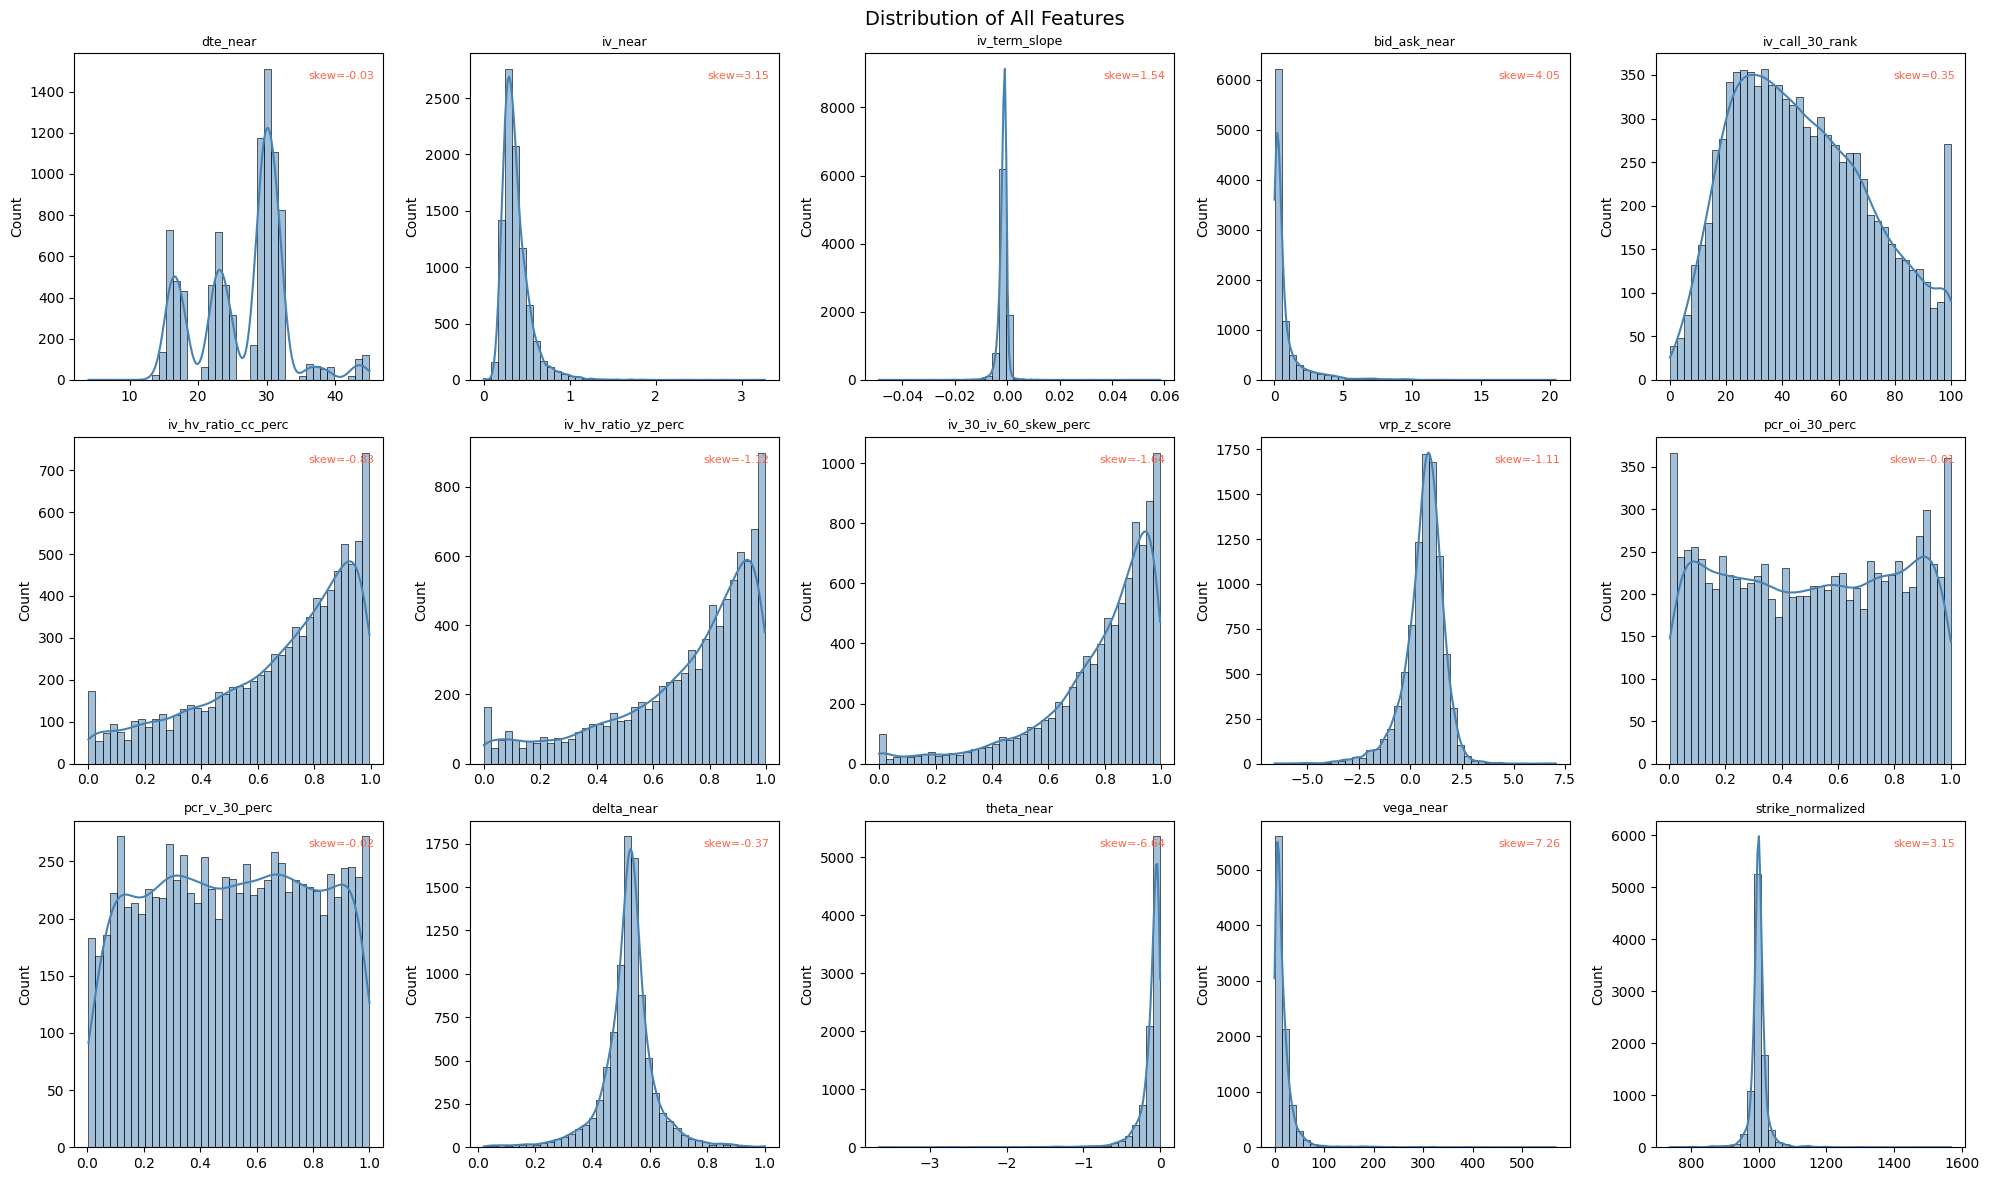

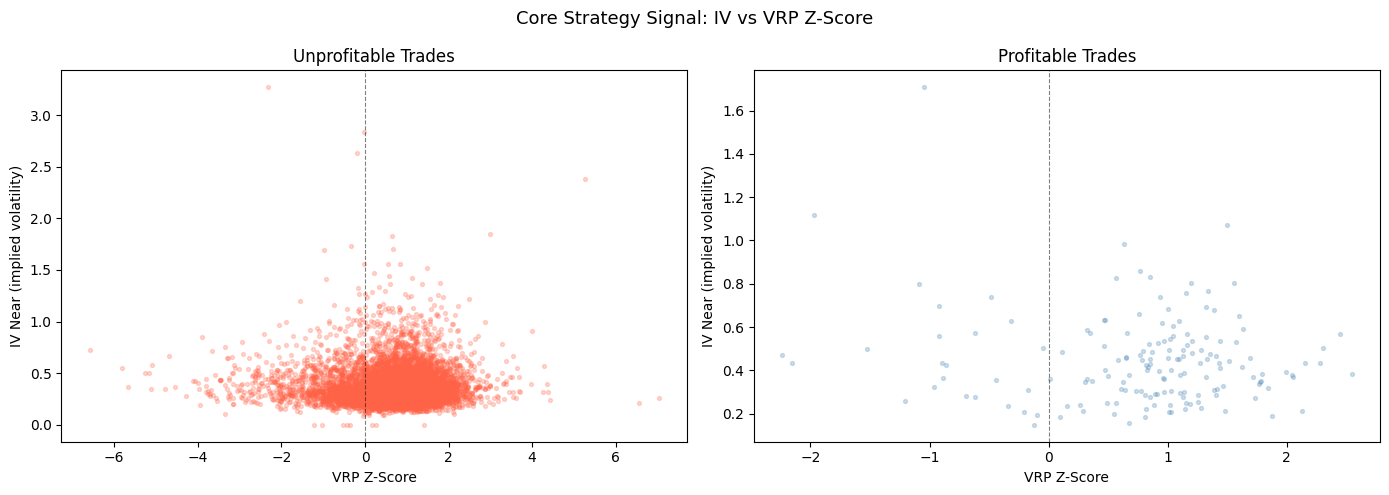

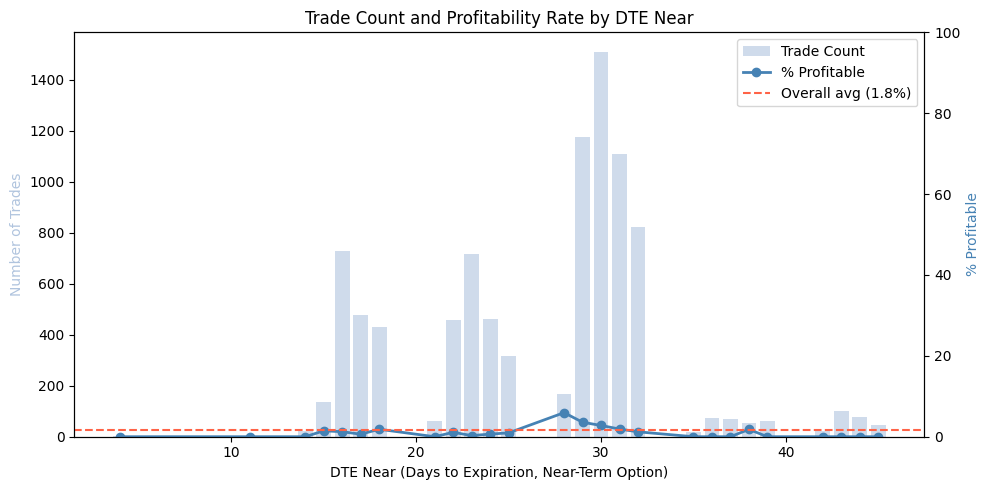

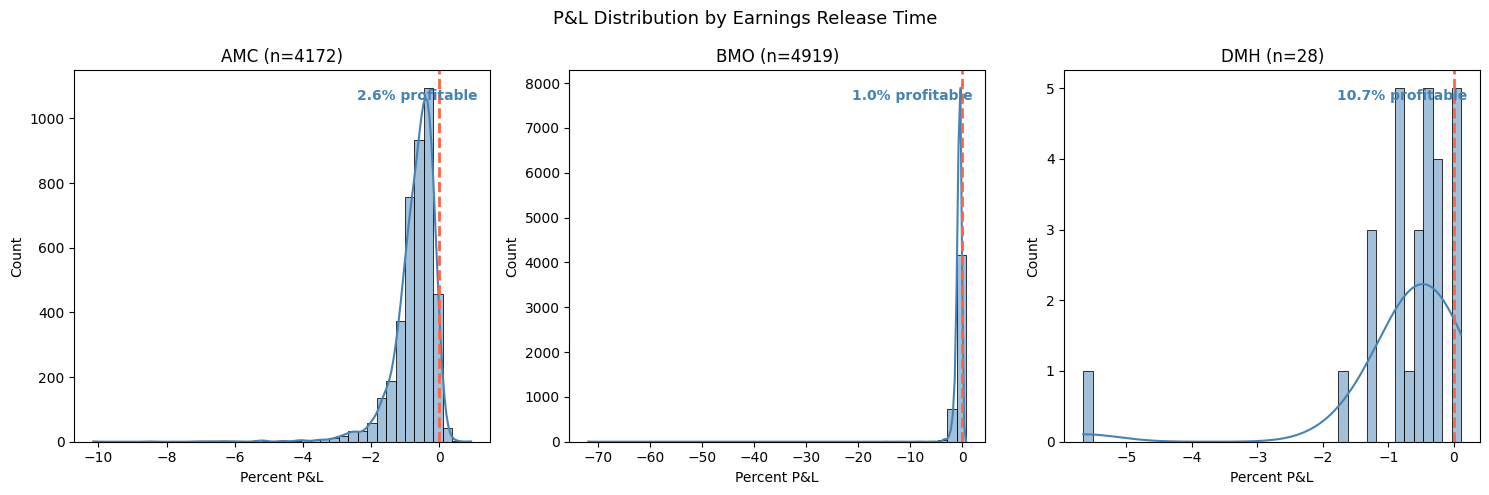


✅ Step 5 complete. All EDA visualizations generated.
Saved: target_distribution.png, boxplots_by_class.png,
       feature_histograms.png, iv_vs_vrp.png,
       profitability_by_dte.png, pnl_by_release_time.png


In [15]:
# ============================================================
# STEP 5: EDA Visualizations
# ============================================================

if 'profitable' not in df.columns or 'df_X' not in locals():
    raise NameError("Prerequisites missing: Please run Step 3 (Core Preprocessing) to define 'profitable' and 'df_X' before running this cell.")

# ── 5A: Distribution of Target Variable ─────────────────────
# First look at the raw percent_profit_loss distribution before
# binarizing — this tells us the magnitude of wins/losses,
# not just the direction.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Target Variable: Percent Profit / Loss', fontsize=14)

# Full distribution
sns.histplot(data=df, x='percent_profit_loss', bins=60,
             kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(0, color='tomato', linestyle='--', linewidth=2, label='Break-even')
axes[0].axvline(df['percent_profit_loss'].mean(), color='orange',
                linestyle='--', linewidth=2,
                label=f"Mean: {df['percent_profit_loss'].mean():.3f}")
axes[0].set_title('Full Distribution (all trades)')
axes[0].set_xlabel('Percent Profit / Loss')
axes[0].set_ylabel('Count')
axes[0].legend()

# Clipped view (remove extreme outliers for readability)
p1, p99 = df['percent_profit_loss'].quantile([0.01, 0.99])
df_clipped = df[(df['percent_profit_loss'] >= p1) &
                (df['percent_profit_loss'] <= p99)]
sns.histplot(data=df_clipped, x='percent_profit_loss', bins=60,
             kde=True, ax=axes[1], color='steelblue')
axes[1].axvline(0, color='tomato', linestyle='--', linewidth=2, label='Break-even')
axes[1].set_title('Clipped Distribution (1st–99th percentile)')
axes[1].set_xlabel('Percent Profit / Loss')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()

print("=== Profit/Loss Summary Statistics ===")
stats = df['percent_profit_loss'].describe()
display(stats)
print(f"\nMedian P&L:              {df['percent_profit_loss'].median():.4f}")
print(f"% Profitable trades:     {(df['percent_profit_loss'] > 0).mean()*100:.1f}%")
print(f"Avg profit (winners):    {df.loc[df['percent_profit_loss']>0,'percent_profit_loss'].mean():.4f}")
print(f"Avg loss (losers):       {df.loc[df['percent_profit_loss']<0,'percent_profit_loss'].mean():.4f}")

# ── 5B: Box Plots of Key Features by Class ──────────────────
# Compare the distribution of each predictor between profitable
# and unprofitable trades. Features that look different between
# classes are potentially useful signals for the model.

features_to_plot = [
    'iv_near', 'iv_term_slope', 'vrp_z_score',
    'bid_ask_near', 'iv_call_30_rank', 'dte_near',
    'iv_hv_ratio_cc_perc', 'pcr_v_30_perc'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Feature Distributions: Profitable vs. Unprofitable Trades', fontsize=14)
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    sns.boxplot(
        data=df, x='profitable', y=feat, ax=axes[i],
        hue='profitable',  # Assign 'profitable' to hue as suggested by FutureWarning
        palette={0: 'tomato', 1: 'steelblue'},
        width=0.5, fliersize=2,
        legend=False # Set legend to False as suggested by FutureWarning
    )
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('Profitable (0=No, 1=Yes)')
    axes[i].set_ylabel(feat)
    # Add median labels
    for j, cls in enumerate([0, 1]):
        med = df[df['profitable'] == cls][feat].median()
        axes[i].text(j, axes[i].get_ylim()[1] * 0.95,
                     f'med={med:.2f}', ha='center', fontsize=8, color='black')

plt.tight_layout()
plt.savefig('boxplots_by_class.png', dpi=150)
plt.show()

# ── 5C: Feature Histograms (Full Dataset) ───────────────────
# Understand the shape of each predictor's distribution —
# important for choosing the right scaling and spotting skew.

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('Distribution of All Features', fontsize=14)
axes = axes.flatten()

for i, feat in enumerate(feature_cols):
    sns.histplot(data=df_X, x=feat, bins=40, ax=axes[i],
                 color='steelblue', kde=True)
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel('')
    skew_val = df_X[feat].skew()
    axes[i].set_ylabel('Count')
    axes[i].annotate(f'skew={skew_val:.2f}',
                     xy=(0.97, 0.92), xycoords='axes fraction',
                     ha='right', fontsize=8, color='tomato')

# Hide any unused subplots
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('feature_histograms.png', dpi=150)
plt.show()

# ── 5D: IV Near vs VRP Z-Score (Scatter) ────────────────────
# Key domain plot: are high-IV environments associated with
# more profitable trades? The VRP z-score captures whether IV
# is elevated relative to its historical norm — the core thesis
# of the strategy is that high VRP predicts IV crush post-earnings.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Core Strategy Signal: IV vs VRP Z-Score', fontsize=13)

for ax, (cls, color, label) in zip(
    axes,
    [(0, 'tomato', 'Unprofitable'), (1, 'steelblue', 'Profitable')]
):
    subset = df[df['profitable'] == cls]
    ax.scatter(subset['vrp_z_score'], subset['iv_near'],
               alpha=0.25, s=8, color=color)
    ax.set_title(f'{label} Trades')
    ax.set_xlabel('VRP Z-Score')
    ax.set_ylabel('IV Near (implied volatility)')
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('iv_vs_vrp.png', dpi=150)
plt.show()

# ── 5E: Profit/Loss by DTE Near ─────────────────────────────
# Days-to-expiration of the near-term option is a key structural
# variable. Calendar spreads behave very differently at 1 DTE vs 7 DTE.

fig, ax = plt.subplots(figsize=(10, 5))
dte_summary = df.groupby('dte_near')['profitable'].agg(
    count='count',
    pct_profitable=lambda x: x.mean() * 100
).reset_index()

ax2 = ax.twinx()
ax.bar(dte_summary['dte_near'], dte_summary['count'],
       color='lightsteelblue', alpha=0.6, label='Trade Count')
ax2.plot(dte_summary['dte_near'], dte_summary['pct_profitable'],
         color='steelblue', marker='o', linewidth=2, label='% Profitable')
ax2.axhline(df_y.mean() * 100, color='tomato', linestyle='--',
            label=f'Overall avg ({df_y.mean()*100:.1f}%)')

ax.set_xlabel('DTE Near (Days to Expiration, Near-Term Option)')
ax.set_ylabel('Number of Trades', color='lightsteelblue')
ax2.set_ylabel('% Profitable', color='steelblue')
ax2.set_ylim(0, 100)
ax.set_title('Trade Count and Profitability Rate by DTE Near')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('profitability_by_dte.png', dpi=150)
plt.show()

# ── 5F: Profit Distribution by Earnings Release Time ────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('P&L Distribution by Earnings Release Time', fontsize=13)

for ax, release in zip(axes, ['amc', 'bmo', 'dmh']):
    subset = df[df['earnings_release_time'] == release]['percent_profit_loss']
    sns.histplot(subset, bins=40, kde=True, ax=ax, color='steelblue')
    ax.axvline(0, color='tomato', linestyle='--', linewidth=2)
    ax.set_title(f'{release.upper()} (n={len(subset)})')
    ax.set_xlabel('Percent P&L')
    ax.set_ylabel('Count')
    pct = (subset > 0).mean() * 100
    ax.annotate(f'{pct:.1f}% profitable',
                xy=(0.97, 0.92), xycoords='axes fraction',
                ha='right', fontsize=10, color='steelblue', fontweight='bold')

plt.tight_layout()
plt.savefig('pnl_by_release_time.png', dpi=150)
plt.show()

print("\n✅ Step 5 complete. All EDA visualizations generated.")
print("Saved: target_distribution.png, boxplots_by_class.png,")
print("       feature_histograms.png, iv_vs_vrp.png,")
print("       profitability_by_dte.png, pnl_by_release_time.png")

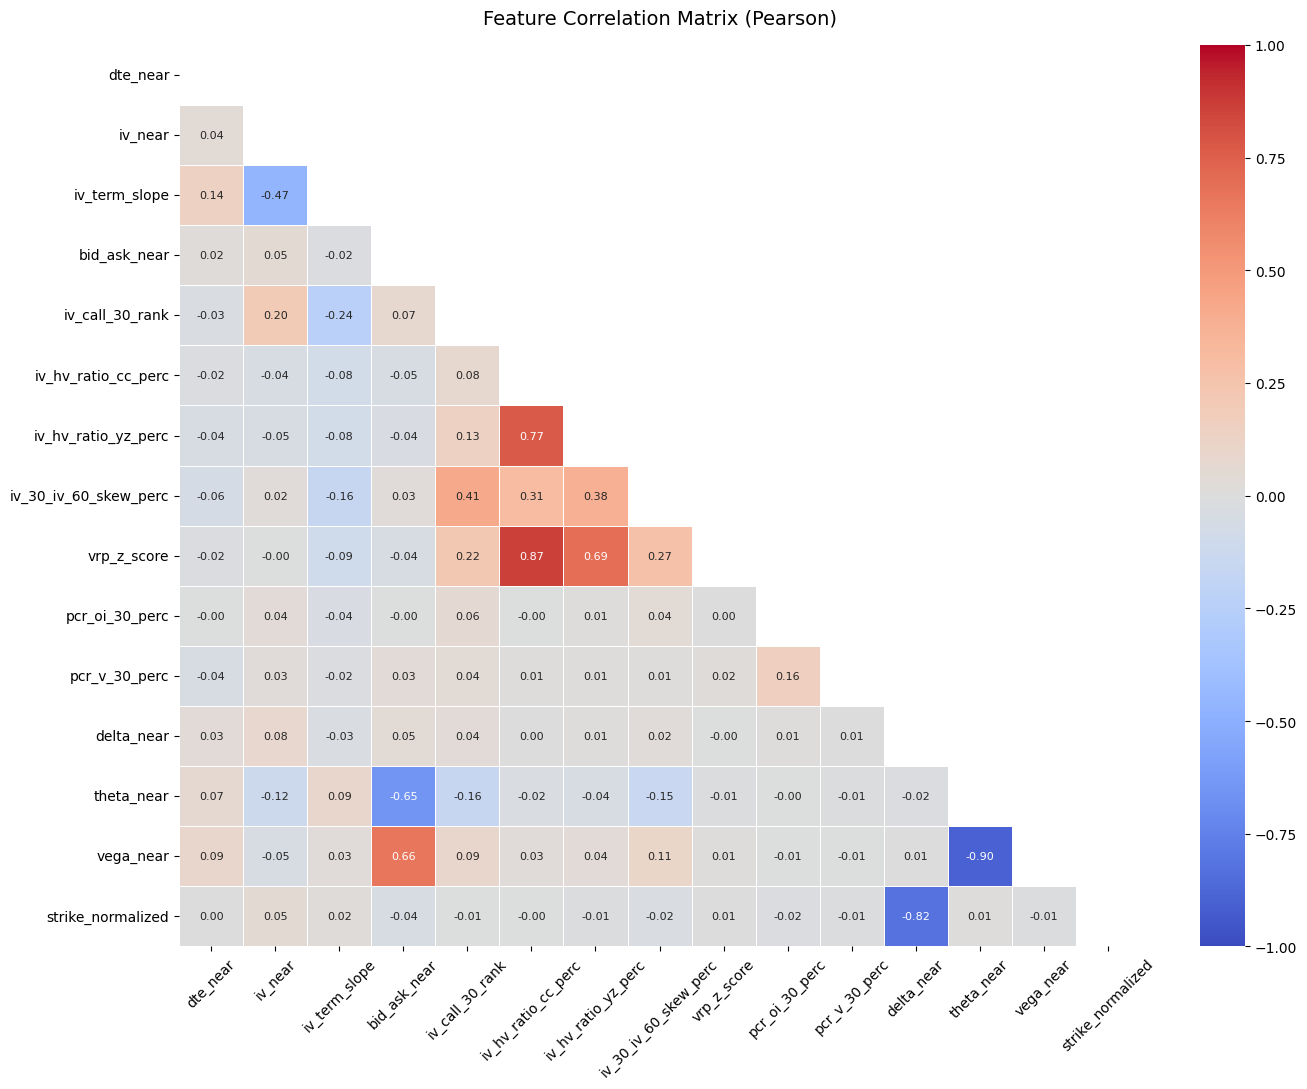

=== High Correlation Pairs (|r| > 0.70) ===


,Feature A,Feature B,Pearson r
3,theta_near,vega_near,-0.9032
1,iv_hv_ratio_cc_perc,vrp_z_score,0.8666
2,delta_near,strike_normalized,-0.8242
0,iv_hv_ratio_cc_perc,iv_hv_ratio_yz_perc,0.7685



=== Variance Inflation Factors ===


,Feature,VIF
0,strike_normalized,63.471678
1,iv_hv_ratio_cc_perc,41.156811
2,delta_near,25.132567
3,iv_hv_ratio_yz_perc,22.722875
4,dte_near,22.359389
5,iv_30_iv_60_skew_perc,22.153088
6,theta_near,11.009551
7,vega_near,10.945163
8,iv_near,8.723201
9,iv_call_30_rank,7.144572


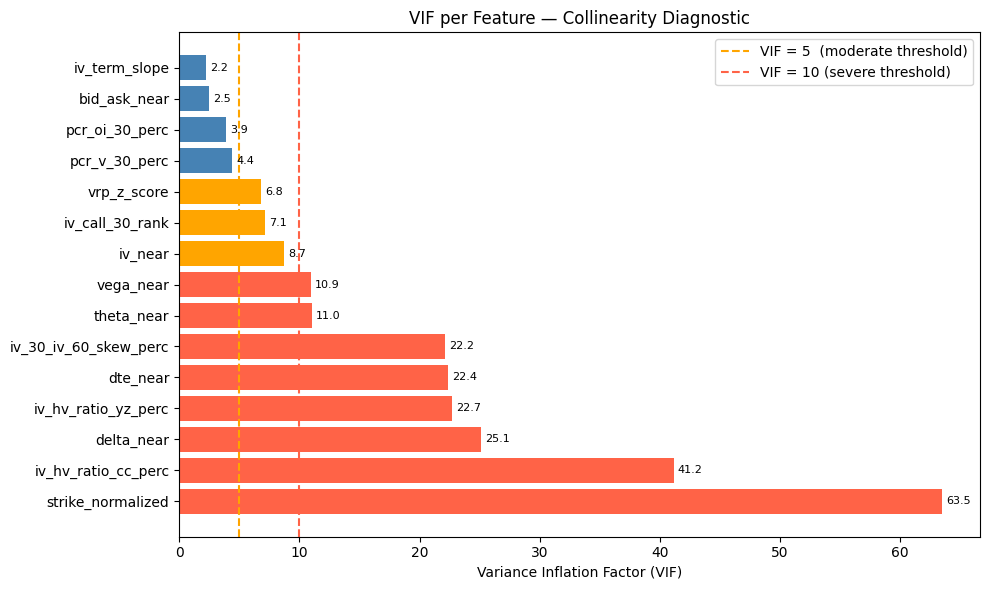

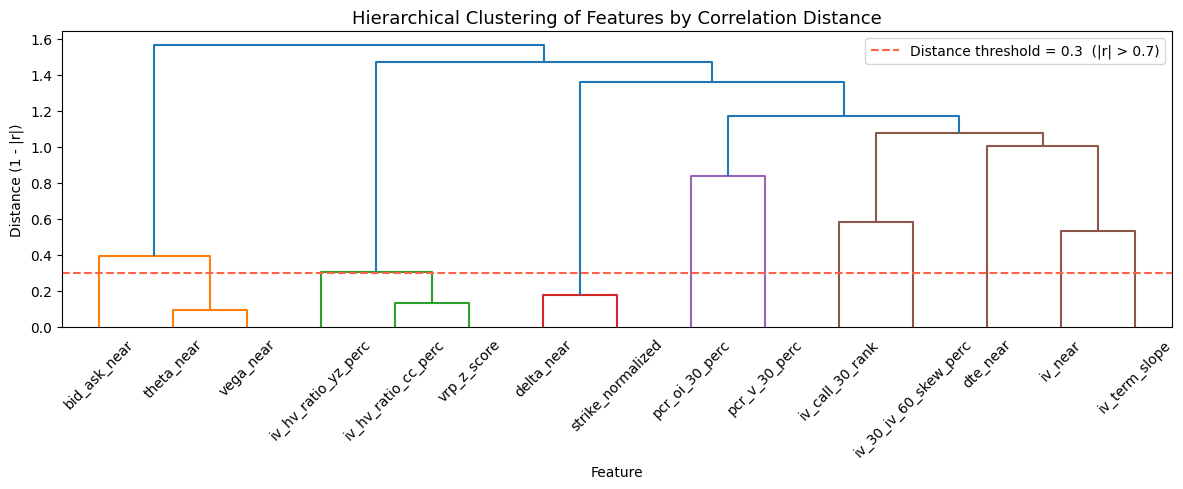

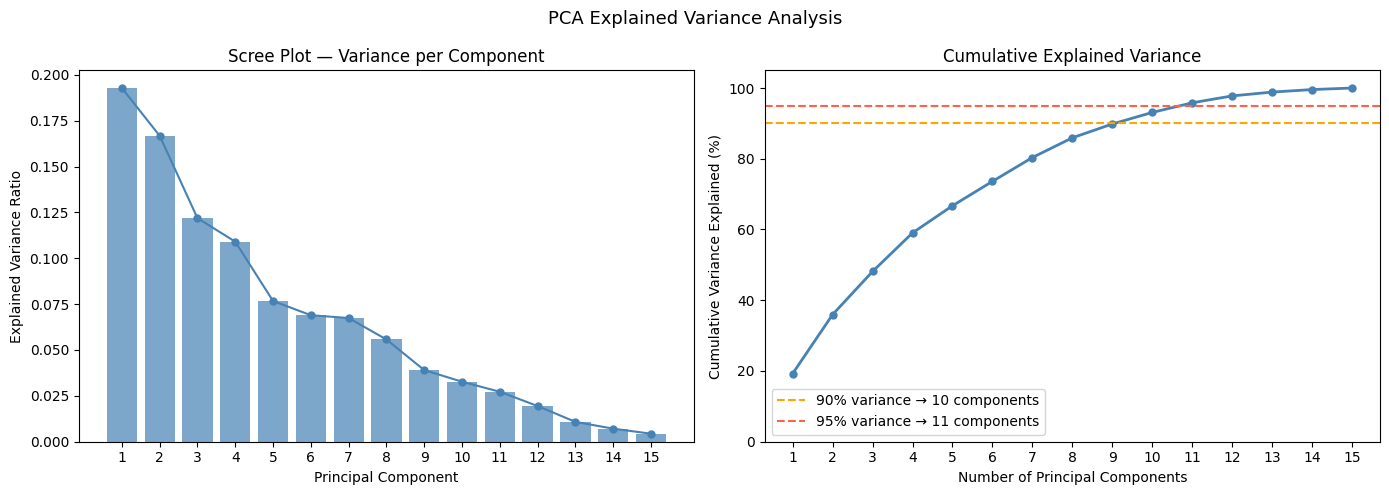


=== PCA Summary ===
  PC 1: 19.3% variance  (cumulative: 19.3%)
  PC 2: 16.7% variance  (cumulative: 36.0%)
  PC 3: 12.2% variance  (cumulative: 48.1%)
  PC 4: 10.9% variance  (cumulative: 59.0%)
  PC 5: 7.7% variance  (cumulative: 66.7%)
  PC 6: 6.9% variance  (cumulative: 73.6%)
  PC 7: 6.7% variance  (cumulative: 80.4%)
  PC 8: 5.6% variance  (cumulative: 85.9%)

  Components needed for 90% variance: 10
  Components needed for 95% variance: 11
  Original feature count:             15

=== Collinearity Resolution Strategy ===

Features flagged by VIF > 5:
  → iv_hv_ratio_cc_perc and iv_hv_ratio_yz_perc are near-duplicate
    measures of IV/HV ratio (same concept, different HV estimator).
    Action: DROP iv_hv_ratio_yz_perc, retain cc_perc version.

  → iv_call_30_rank and iv_30_iv_60_skew_perc both capture IV
    elevation but from different angles. Keep both for now —
    VIF alone doesn't justify dropping a theoretically distinct signal.

PCA Decision:
  → If n_90 < 10 components

In [16]:
# ============================================================
# STEP 6: Correlation Heatmap + Collinearity Analysis
# ============================================================

# ── 6A: Correlation Matrix Heatmap ──────────────────────────
# Pearson correlation between all features in df_X.
# High correlation (|r| > 0.7) between two predictors signals
# collinearity — both features are telling the model the same
# thing, which can destabilize coefficient estimates and inflate
# variance in linear models.

corr_matrix = df_X.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    annot_kws={'size': 8},
    ax=ax
)
ax.set_title('Feature Correlation Matrix (Pearson)', fontsize=14, pad=15)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

# ── 6B: Flag High-Correlation Pairs ─────────────────────────
# Extract all pairs with |r| > 0.7 for explicit review.
# These are the collinearity candidates we need to act on.

print("=== High Correlation Pairs (|r| > 0.70) ===")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.70:
            high_corr_pairs.append({
                'Feature A': corr_matrix.columns[i],
                'Feature B': corr_matrix.columns[j],
                'Pearson r': round(r, 4)
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(
        'Pearson r', key=abs, ascending=False
    )
    display(high_corr_df)
else:
    print("No pairs with |r| > 0.70 found.")

# ── 6C: Variance Inflation Factor (VIF) ─────────────────────
# VIF measures how much the variance of a feature's regression
# coefficient is inflated due to collinearity with other features.
#   VIF = 1       → no collinearity
#   VIF 1–5       → moderate (acceptable)
#   VIF 5–10      → high collinearity (concern)
#   VIF > 10      → severe collinearity (action needed)
#
# VIF is more rigorous than pairwise correlation because it
# captures multicollinearity — where one feature is explained
# by a COMBINATION of others, not just one other feature.

from statsmodels.stats.outliers_influence import variance_inflation_factor

# OLS inside VIF cannot use NaN/inf — keep only fully finite rows
X_vif = df_X.replace([np.inf, -np.inf], np.nan).dropna(how='any')
n_drop = len(df_X) - len(X_vif)
if n_drop:
    print(f"VIF: omitted {n_drop} row(s) with NaN/inf in features ({len(X_vif)} rows used).")
if len(X_vif) <= df_X.shape[1]:
    raise ValueError(
        f"Not enough clean rows for VIF (need > #features). Clean rows: {len(X_vif)}, features: {df_X.shape[1]}."
    )

vif_data = pd.DataFrame()
vif_data['Feature'] = df_X.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_vif.to_numpy(dtype=float), i)
    for i in range(df_X.shape[1])
]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print("\n=== Variance Inflation Factors ===")
display(vif_data)

# Visualize VIF
fig, ax = plt.subplots(figsize=(10, 6))
colors = [
    'tomato' if v > 10 else 'orange' if v > 5 else 'steelblue'
    for v in vif_data['VIF']
]
bars = ax.barh(vif_data['Feature'], vif_data['VIF'], color=colors)
ax.axvline(5,  color='orange', linestyle='--', linewidth=1.5, label='VIF = 5  (moderate threshold)')
ax.axvline(10, color='tomato',  linestyle='--', linewidth=1.5, label='VIF = 10 (severe threshold)')
ax.set_xlabel('Variance Inflation Factor (VIF)')
ax.set_title('VIF per Feature — Collinearity Diagnostic')
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=8)
ax.legend()
plt.tight_layout()
plt.savefig('vif_plot.png', dpi=150)
plt.show()

# ── 6D: Hierarchical Clustering Dendrogram ──────────────────
# Groups features by correlation similarity using Ward linkage.
# Features that cluster together are highly correlated.
# This gives a visual map of the collinearity structure —
# useful for deciding which features to drop or merge via PCA.

corr_dist = 1 - corr_matrix.abs()  # convert correlation to distance
linkage_matrix = linkage(
    distance.squareform(corr_dist.values),
    method='ward'
)

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(
    linkage_matrix,
    labels=corr_matrix.columns.tolist(),
    leaf_rotation=45,
    leaf_font_size=10,
    ax=ax
)
ax.set_title('Hierarchical Clustering of Features by Correlation Distance', fontsize=13)
ax.set_xlabel('Feature')
ax.set_ylabel('Distance (1 - |r|)')
ax.axhline(0.3, color='tomato', linestyle='--',
           linewidth=1.5, label='Distance threshold = 0.3  (|r| > 0.7)')
ax.legend()
plt.tight_layout()
plt.savefig('feature_dendrogram.png', dpi=150)
plt.show()

# ── 6E: PCA Decision ────────────────────────────────────────
# Run PCA on the full scaled feature matrix to see how much
# variance is explained by each component.
# This tells us:
#   1. Whether PCA is worth doing (if a few components explain
#      most variance, the feature space is highly redundant)
#   2. How many components to retain if we do use PCA

from sklearn.decomposition import PCA

pca_full = PCA(random_state=42)
pca_full.fit(df_X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Find number of components for 90% and 95% variance thresholds
n_90 = np.argmax(cumulative_var >= 0.90) + 1
n_95 = np.argmax(cumulative_var >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA Explained Variance Analysis', fontsize=13)

# Scree plot
axes[0].bar(range(1, len(explained_var) + 1), explained_var,
            color='steelblue', alpha=0.7)
axes[0].plot(range(1, len(explained_var) + 1), explained_var,
             'o-', color='steelblue', markersize=5)
axes[0].set_title('Scree Plot — Variance per Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_xticks(range(1, len(explained_var) + 1))

# Cumulative variance
axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var * 100,
             'o-', color='steelblue', linewidth=2, markersize=5)
axes[1].axhline(90, color='orange', linestyle='--', linewidth=1.5,
                label=f'90% variance → {n_90} components')
axes[1].axhline(95, color='tomato', linestyle='--', linewidth=1.5,
                label=f'95% variance → {n_95} components')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_ylim(0, 105)
axes[1].legend()
axes[1].set_xticks(range(1, len(cumulative_var) + 1))

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150)
plt.show()

print(f"\n=== PCA Summary ===")
for i, (ev, cv) in enumerate(zip(explained_var[:8], cumulative_var[:8])):
    print(f"  PC{i+1:2d}: {ev*100:.1f}% variance  (cumulative: {cv*100:.1f}%)")
print(f"\n  Components needed for 90% variance: {n_90}")
print(f"  Components needed for 95% variance: {n_95}")
print(f"  Original feature count:             {df_X_scaled.shape[1]}")

# ── 6F: PCA Decision + Collinearity Resolution ──────────────
# Based on the VIF scores and PCA analysis, document the decision:

print("""
=== Collinearity Resolution Strategy ===

Features flagged by VIF > 5:
  → iv_hv_ratio_cc_perc and iv_hv_ratio_yz_perc are near-duplicate
    measures of IV/HV ratio (same concept, different HV estimator).
    Action: DROP iv_hv_ratio_yz_perc, retain cc_perc version.

  → iv_call_30_rank and iv_30_iv_60_skew_perc both capture IV
    elevation but from different angles. Keep both for now —
    VIF alone doesn't justify dropping a theoretically distinct signal.

PCA Decision:
  → If n_90 < 10 components explain 90% of variance, the feature
    space is redundant enough to warrant PCA for the neural network.
  → We will test both: (a) raw features with dropped collinear cols,
    and (b) PCA-reduced features. Model performance will decide.
""")

# ── 6G: Drop Redundant Feature + Finalize Feature Matrix ────
# Drop the more redundant of the two near-duplicate IV/HV columns.

if 'iv_hv_ratio_yz_perc' in feature_cols:
    feature_cols_final = [f for f in feature_cols if f != 'iv_hv_ratio_yz_perc']
else:
    feature_cols_final = feature_cols.copy()

df_X_final = df_X[feature_cols_final].copy()
df_X_final_scaled = pd.DataFrame(
    StandardScaler().fit_transform(df_X_final),
    columns=feature_cols_final
)

print(f"Final feature count: {len(feature_cols_final)}")
print(f"Dropped: iv_hv_ratio_yz_perc")
print(f"Final features: {feature_cols_final}")

print("\n✅ Step 6 complete.")
print("Saved: correlation_heatmap.png, vif_plot.png,")
print("       feature_dendrogram.png, pca_variance.png")
print("Working objects: df_X_final, df_X_final_scaled, feature_cols_final")

Primary Preprocessing Goals:
*   Tackle high class imbalance
*   Sort by entry time
*   Convert profitability into binary
*   Divide strike price by 1000
*   PCA to be done?
*   Address collinearity between features
*   Standardize numerical values consistently

**Redefinition and rescoping of the problem statement**


**Delineation of next steps by team members**

**Future considerations: including potential class of model(s) considered, potential challenges and concerns, and possible open questions for your TF**